# Examples of use of `scipy` library



In [1]:
import scipy.optimize as opt
import numpy as np

## Considered problem
$$\begin{align}
\min_{x_0,x_1} &f(x)\\
\text{subject to}&\begin{cases}
x_0+2x_1\leq1\\
x_0^2+x_1\leq1\\
x_0^2-x_1\leq1\\
2x_0+x_1=1\\
0\leq x_0\leq1\\
-0.5\leq x_1\leq 2
\end{cases}
\end{align}$$

avec $f(\mathbf{x})=100(x_1-x_0^2)^2+(1-x_0)^2$

## Definition of the objective function (and gradient)

In [2]:
funObj= lambda x: 100*(x[1]-x[0]**2)**2 + (1-x[0])**2
funGradObj=lambda x: np.array([-400*x[0]*(x[1]-x[0]**2)-2*(1-x[0]),200*(x[1]-x[0]**2)])

In [3]:
import matplotlib.pyplot as plt

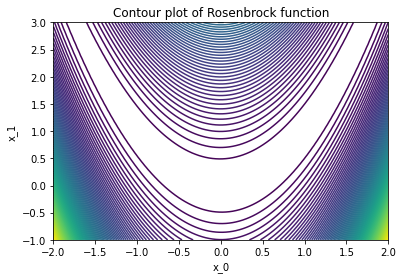

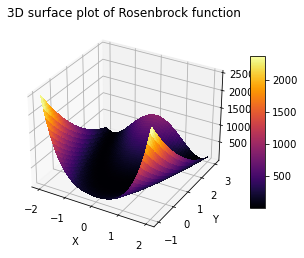

In [4]:
gX,gY=np.meshgrid(np.linspace(-2,2,100),np.linspace(-1,3,100))
gZ = funObj([gX,gY])
plt.contour(gX,gY,gZ,100)
plt.xlabel('x_0')
plt.ylabel('x_1')
plt.title('Contour plot of Rosenbrock function')

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(gX,gY,gZ, cmap='inferno', linewidth=0, antialiased=False)

fig.colorbar(surface, shrink=0.7, aspect=10)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D surface plot of Rosenbrock function')

plt.show()

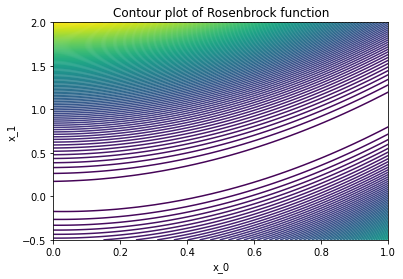

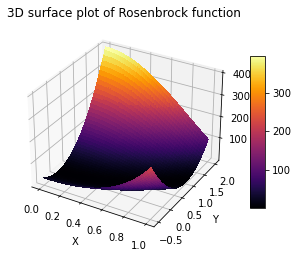

In [5]:
gX,gY=np.meshgrid(np.linspace(0,1,100),np.linspace(-0.5,2,100))
gZ = funObj([gX,gY])
plt.contour(gX,gY,gZ,100)
plt.xlabel('x_0')
plt.ylabel('x_1')
plt.title('Contour plot of Rosenbrock function')

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(gX,gY,gZ, cmap='inferno', linewidth=0, antialiased=False)

fig.colorbar(surface, shrink=0.7, aspect=10)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D surface plot of Rosenbrock function')

plt.show()

## Definition of constraints

### 1. with provided gradients


In [6]:
ineq_cons_w_grad = {'type': 'ineq',
             'fun' : lambda x: np.array([1 - x[0] - 2*x[1],
                                         1 - x[0]**2 - x[1],
                                         1 - x[0]**2 + x[1]]),
             'jac' : lambda x: np.array([[-1.0, -2.0],
                                         [-2*x[0], -1.0],
                                         [-2*x[0], 1.0]])}

eq_cons_w_grad = {'type': 'eq',
           'fun' : lambda x: np.array([2*x[0] + x[1] - 1]),
           'jac' : lambda x: np.array([2.0, 1.0])}

### 2. without gradients

In [7]:
ineq_cons_wo_grad = {'type': 'ineq',
             'fun' : lambda x: np.array([1 - x[0] - 2*x[1],
                                         1 - x[0]**2 - x[1],
                                         1 - x[0]**2 + x[1]])}

eq_cons_wo_grad = {'type': 'eq',
           'fun' : lambda x: np.array([2*x[0] + x[1] - 1])}

## Run of optimization

### Set of parameters bounds

In [8]:
# bounds = opt.Bounds([0, -0.5], [1.0, 2.0])
bounds = [(0,1),(-0.5,2)]

### Execution of gradient-based optimization

In [9]:

## 
x0 = np.array([0.5, 0])
res = opt.minimize(funObj,
                x0, 
               method='SLSQP', 
               jac=funGradObj,
               constraints=[eq_cons_w_grad, ineq_cons_w_grad], 
               options={'ftol': 1e-9, 'disp': True},
               bounds=bounds)
print(res)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.34271757499419825
            Iterations: 4
            Function evaluations: 5
            Gradient evaluations: 4
     fun: 0.34271757499419825
     jac: array([-0.82676145, -0.41372864])
 message: 'Optimization terminated successfully'
    nfev: 5
     nit: 4
    njev: 4
  status: 0
 success: True
       x: array([0.41494475, 0.1701105 ])


### Execution of optimization without gradients

In [10]:
## 
x0 = np.array([0.5, 0])
res = opt.minimize(funObj,
                x0, 
               method='SLSQP', 
               jac=None,
               constraints=[eq_cons_wo_grad, ineq_cons_wo_grad], 
               options={'ftol': 1e-9, 'disp': True},
               bounds=bounds)
print(res)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.34271757499503896
            Iterations: 4
            Function evaluations: 13
            Gradient evaluations: 4
     fun: 0.34271757499503896
     jac: array([-0.82675983, -0.41372783])
 message: 'Optimization terminated successfully'
    nfev: 13
     nit: 4
    njev: 4
  status: 0
 success: True
       x: array([0.41494475, 0.1701105 ])


### Extract optimization data along iterations

#### Class for storage

In [11]:
class objStore:
    def __init__(self):
        self.x=[]
        self.fun=[]
    def store(self,x,f):
        self.x.append(x)
        self.fun.append(f)
data = objStore()

### modification of the objective function to store the data

In [12]:
def funObjMod(x):
    f = funObj(x)
    data.store(x,f)
    return f

### Run optimization

In [13]:
x0 = np.array([0.5, 0])
res = opt.minimize(funObjMod,
                x0, 
               method='SLSQP', 
               jac=None,
               constraints=[eq_cons_wo_grad, ineq_cons_wo_grad], 
               options={'ftol': 1e-9, 'disp': True},
               bounds=bounds)
print(res)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.34271757499503896
            Iterations: 4
            Function evaluations: 13
            Gradient evaluations: 4
     fun: 0.34271757499503896
     jac: array([-0.82675983, -0.41372783])
 message: 'Optimization terminated successfully'
    nfev: 13
     nit: 4
    njev: 4
  status: 0
 success: True
       x: array([0.41494475, 0.1701105 ])


In [14]:
print(data.x)

[array([0.5, 0. ]), array([0.50000001, 0.        ]), array([5.00000000e-01, 1.49011612e-08]), array([0.33333333, 0.33333333]), array([0.41274076, 0.17451848]), array([0.41274077, 0.17451848]), array([0.41274076, 0.17451849]), array([0.4147587 , 0.17048259]), array([0.41475872, 0.17048259]), array([0.4147587 , 0.17048261]), array([0.41494475, 0.1701105 ]), array([0.41494477, 0.1701105 ]), array([0.41494475, 0.17011051])]


Text(0, 0.5, 'Objective value')

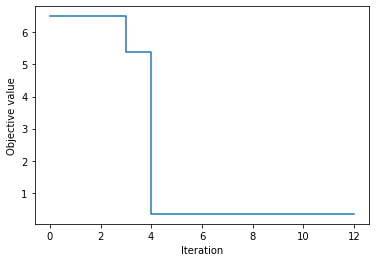

In [15]:
plt.step(range(len(data.x)),data.fun,where='post')
plt.xlabel('Iteration')
plt.ylabel('Objective value')